In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from pycox.models import DeepHitSingle
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

from DeepHitAtencjuszClass import AttentionDeepHit

In [2]:
import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

In [43]:
#from Preprocessing.PreprocessingBrainCancer import prepare_brain_cancer_data as prepare_data
#from Preprocessing.PreprocessingBreastCancer import prepare_breast_cancer_data as prepare_data
#from Preprocessing.PreprocessingLeukemia import prepare_leukemia_data as prepare_data 
#from Preprocessing.PreprocessingLungCancer import prepare_lung_cancer_data as prepare_data
#from Preprocessing.PreprocessingLymphoma import prepare_lymphoma_data as prepare_data
#from Preprocessing.PreprocessingProstateCancer import prepare_prostate_cancer_data as prepare_data
from Preprocessing.PreprocessingSmallIntestineCancer import prepare_small_intestine_cancer_data as prepare_data

datasets_paths_list = [
    "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\_BrainCancerUsaDataset.csv",
    "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\_BreastCancerUsaDataset.csv",
    "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\_LeukemiaUsaDataset.csv",
    "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\_LungCancerUsaDataset.csv",
    "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\_LymphomaUsaDataset.csv",
    "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\_ProstateCancerUsaDataset.csv",
    "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\_SmallIntestineCancerUsaDataset.csv"
]

#laptop
# C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\

#komputer dom
# C:\\Users\\kubap\\OneDrive\\Pulpit\\magisterka ekperymenty\\Datasets\\

x_train, y_train, val_data, x_test, y_test = prepare_data("C:\\Users\\kubap\\OneDrive\\Pulpit\\magisterka ekperymenty\\Datasets\\_SmallIntestineCancerUsaDataset.csv")

Dane wczytane. Rozmiar początkowy: (21347, 24)

Rozmiar X_train: (12615, 67)


In [44]:
num_durations = 100
labtrans = LabTransDiscreteTime(num_durations)
y_train_discrete = labtrans.fit_transform(*y_train)
y_val_discrete = labtrans.transform(*val_data[1])
val_data_discrete = (val_data[0], y_val_discrete)

in_features = x_train.shape[1]
out_features = labtrans.out_features 

In [45]:
net = AttentionDeepHit(
    in_features=in_features, 
    num_nodes=[32, 32], 
    out_features=out_features,
    dropout=0.5
)

In [46]:
#inicjalizacja modelu
optimizer = tt.optim.Adam(weight_decay=0.01)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = DeepHitSingle(
    net, 
    optimizer, 
    alpha=0.2, 
    sigma=0.1, 
    duration_index=labtrans.cuts,
    device=device
)

model.optimizer.set_lr(0.0001)

Rozpoczęcie uczenia modelu AttentionDeepHit...
0:	[0s / 0s],		train_loss: 1.0940,	val_loss: 0.8771
1:	[0s / 1s],		train_loss: 1.0046,	val_loss: 0.8796
2:	[0s / 1s],		train_loss: 1.2507,	val_loss: 0.8780
3:	[0s / 2s],		train_loss: 1.0564,	val_loss: 0.8769
4:	[0s / 2s],		train_loss: 0.8924,	val_loss: 0.8774
5:	[0s / 3s],		train_loss: 1.0662,	val_loss: 0.8763
6:	[0s / 3s],		train_loss: 0.9016,	val_loss: 0.8769
7:	[0s / 4s],		train_loss: 0.8806,	val_loss: 0.8766
8:	[0s / 5s],		train_loss: 0.8787,	val_loss: 0.8761
9:	[0s / 5s],		train_loss: 0.8910,	val_loss: 0.8752
10:	[0s / 6s],		train_loss: 0.8964,	val_loss: 0.8745
11:	[0s / 6s],		train_loss: 0.8741,	val_loss: 0.8746
12:	[1s / 7s],		train_loss: 0.8731,	val_loss: 0.8740
13:	[0s / 8s],		train_loss: 1.0134,	val_loss: 0.8743
14:	[1s / 9s],		train_loss: 0.8733,	val_loss: 0.8738
15:	[1s / 11s],		train_loss: 0.8774,	val_loss: 0.8732
16:	[1s / 12s],		train_loss: 0.8721,	val_loss: 0.8727
17:	[1s / 13s],		train_loss: 0.8795,	val_loss: 0.8723
18:	[0

<Figure size 800x400 with 0 Axes>

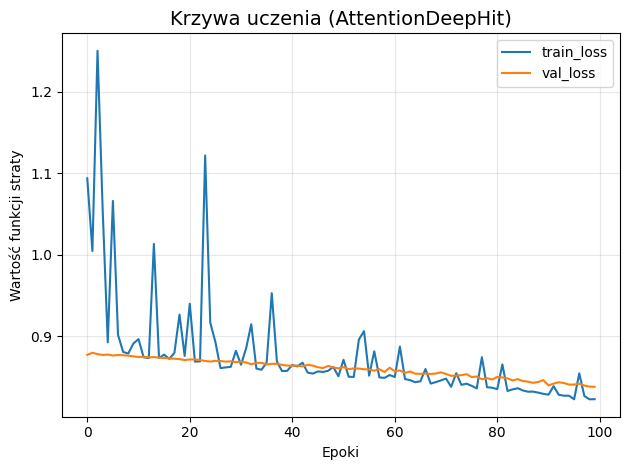

In [47]:
# Uczenie Modelu
batch_size = 256
epochs = 100
callbacks = [tt.callbacks.EarlyStopping(patience=10)]

print("Rozpoczęcie uczenia modelu AttentionDeepHit...")
log = model.fit(x_train, y_train_discrete, batch_size, epochs, callbacks, val_data=val_data_discrete)

# wykres funkcji straty podczas uczenia
plt.figure(figsize=(8, 4))
_ = log.plot()
plt.title("Krzywa uczenia (AttentionDeepHit)", fontsize=14)
plt.xlabel("Epoki")
plt.ylabel("Wartość funkcji straty")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
surv_test = model.predict_surv_df(x_test)

ev = EvalSurv(surv_test, y_test[0], y_test[1], censor_surv='km')

# C-index
c_index = ev.concordance_td()
print(f"Time-Dependent Concordance Index (C-index): {c_index:.4f}")

import scipy.integrate
if not hasattr(scipy.integrate, "simps"):
    scipy.integrate.simps = scipy.integrate.simpson

# Integrated Brier Score
time_grid = np.linspace(y_test[0].min(), y_test[0].max(), 100)
integrated_brier_score = ev.integrated_brier_score(time_grid)
print(f"Integrated Brier Score (IBS): {integrated_brier_score:.4f}")

# Brier Score w czasie
brier_score_time = ev.brier_score(time_grid)

Time-Dependent Concordance Index (C-index): 0.7082
Integrated Brier Score (IBS): 0.2220


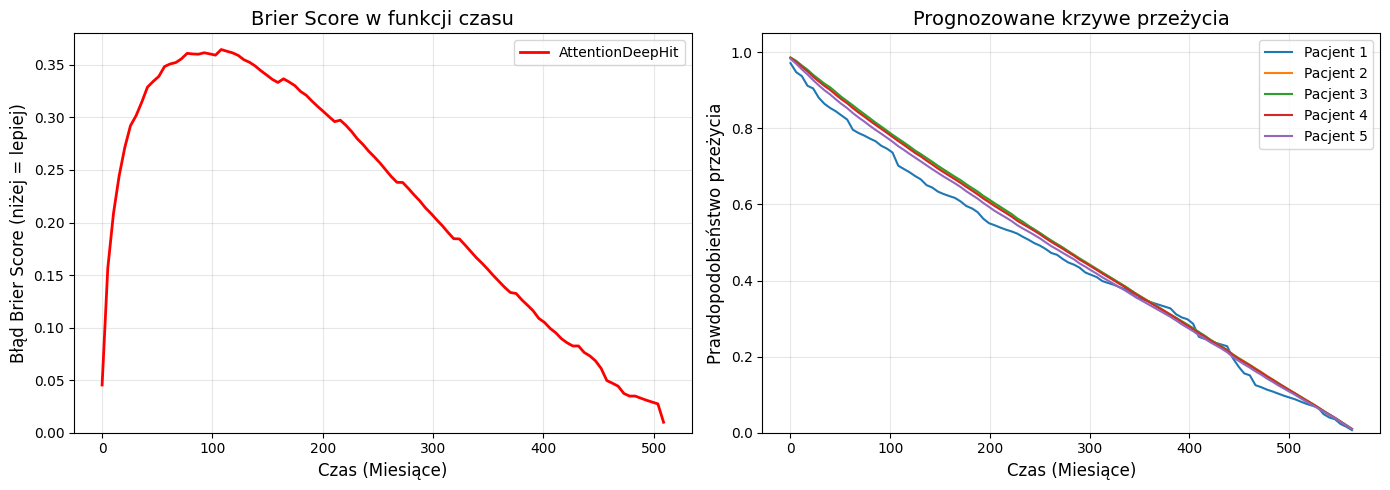

In [51]:
plt.figure(figsize=(14, 5))

# Brier Score w funkcji czasu
plt.subplot(1, 2, 1)
plt.plot(time_grid, brier_score_time, color='red', linewidth=2, label='AttentionDeepHit')
plt.title("Brier Score w funkcji czasu", fontsize=14)
plt.xlabel("Czas (Miesiące)", fontsize=12)
plt.ylabel("Błąd Brier Score (niżej = lepiej)", fontsize=12)
plt.ylim(0, 0.38) 
plt.grid(True, alpha=0.3)
plt.legend()

# krzywe przeżycia dla 5 pierwszych pacjentów testowych
plt.subplot(1, 2, 2)
for i in range(5):
    plt.plot(surv_test.index, surv_test.iloc[:, i], label=f'Pacjent {i+1}')
plt.title("Prognozowane krzywe przeżycia", fontsize=14)
plt.xlabel("Czas (Miesiące)", fontsize=12)
plt.ylabel("Prawdopodobieństwo przeżycia", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

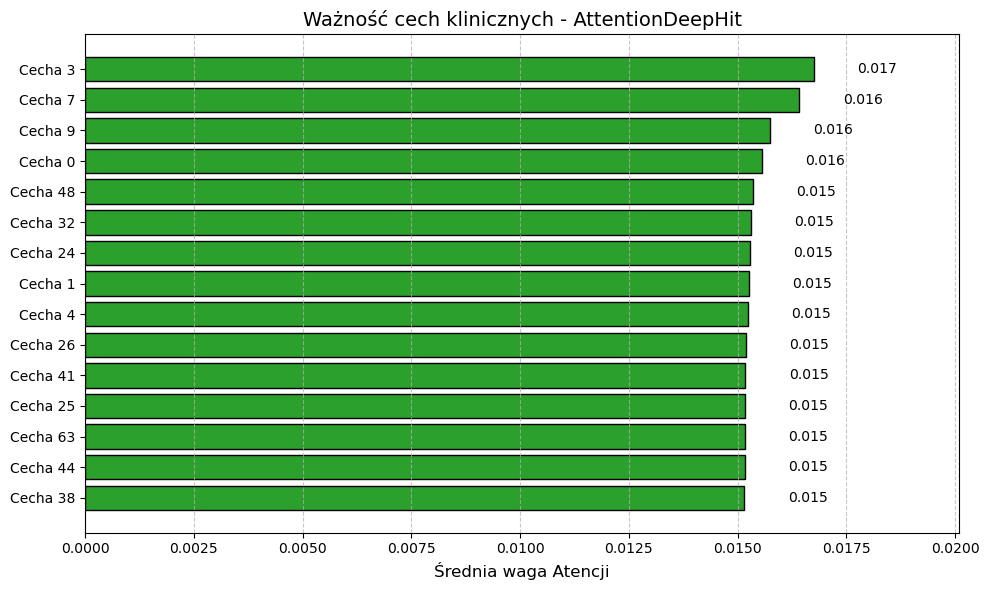

In [81]:
# Konwersja macierzy testowej na tensor PyTorch
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

attention_weights = model.net.get_attention_weights(x_test_tensor)

global_importance = attention_weights.mean(dim=0).numpy()

names = [f"Cecha {i}" for i in range(len(global_importance))]

# Sortowanie cech
sorted_indices = np.argsort(global_importance)
sorted_importance = global_importance[sorted_indices]
sorted_features = [names[i] for i in sorted_indices]

# top 15 najważniejszych cech
top_k = 15
if len(sorted_importance) > top_k:
    sorted_importance = sorted_importance[-top_k:]
    sorted_features = sorted_features[-top_k:]

# wykres atencji cech
plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features, sorted_importance, color='#2ca02c', edgecolor='black')

for bar in bars:
    plt.text(
        bar.get_width() + 0.001, 
        bar.get_y() + bar.get_height()/2, 
        f'{bar.get_width():.3f}', 
        va='center', 
        fontsize=10
    )

plt.title("Ważność cech klinicznych - AttentionDeepHit", fontsize=14)
plt.xlabel("Średnia waga Atencji", fontsize=12)
plt.xlim(0, max(sorted_importance) * 1.2)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import datetime
import os
import matplotlib.pyplot as plt
import torch
import torchtuples as tt

from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from pycox.models import DeepHitSingle
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from DeepHitAtencjuszClass import AttentionDeepHit


from Preprocessing.PreprocessingBrainCancer import prepare_brain_cancer_data
from Preprocessing.PreprocessingBreastCancer import prepare_breast_cancer_data
from Preprocessing.PreprocessingLeukemia import prepare_leukemia_data
from Preprocessing.PreprocessingLungCancer import prepare_lung_cancer_data
from Preprocessing.PreprocessingLymphoma import prepare_lymphoma_data
from Preprocessing.PreprocessingProstateCancer import prepare_prostate_cancer_data
from Preprocessing.PreprocessingSmallIntestineCancer import prepare_small_intestine_cancer_data

base_path = "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\"
datasets = {
    "Brain Cancer": (prepare_brain_cancer_data, base_path + "_BrainCancerUsaDataset.csv"),
    "Breast Cancer": (prepare_breast_cancer_data, base_path + "_BreastCancerUsaDataset.csv"),
    "Leukemia": (prepare_leukemia_data, base_path + "_LeukemiaUsaDataset.csv"),
    "Lung Cancer": (prepare_lung_cancer_data, base_path + "_LungCancerUsaDataset.csv"),
    "Lymphoma": (prepare_lymphoma_data, base_path + "_LymphomaUsaDataset.csv"),
    "Prostate Cancer": (prepare_prostate_cancer_data, base_path + "_ProstateCancerUsaDataset.csv"),
    "Small Intestine Cancer": (prepare_small_intestine_cancer_data, base_path + "_SmallIntestineCancerUsaDataset.csv")
}


output_folder = "Wykresy_Eksperymenty_DHitAtencjusz"
os.makedirs(output_folder, exist_ok=True)

def run_single_experiment(x_train, y_train_discrete, val_data_discrete, x_test, y_test, labtrans):
    
    in_features = x_train.shape[1]
    out_features = labtrans.out_features 
    
    net = AttentionDeepHit(
    in_features=in_features, 
    num_nodes=[32, 32], 
    out_features=out_features,
    dropout=0.3)
    optimizer = tt.optim.Adam(weight_decay=0.01)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = DeepHitSingle(
        net, 
        optimizer, 
        alpha=0.2, 
        sigma=0.1, 
        duration_index=labtrans.cuts,
        device=device)

    model.optimizer.set_lr(0.0001)
    batch_size = 256
    epochs = 100
    callbacks = [tt.callbacks.EarlyStopping(patience=10)]
    
    log = model.fit(x_train, y_train_discrete, batch_size, epochs, callbacks, val_data=val_data_discrete)
    
    # EWALUACJA
    surv_test = model.predict_surv_df(x_test)
    ev = EvalSurv(surv_test, y_test[0], y_test[1], censor_surv='km')
    c_index = ev.concordance_td()
    
    time_grid = np.linspace(y_test[0].min(), y_test[0].max(), 100)
    ibs = ev.integrated_brier_score(time_grid)
    brier_score_time = ev.brier_score(time_grid)
    
    device = next(model.net.parameters()).device
    x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to(device)
    attention_weights = model.net.get_attention_weights(x_test_tensor).mean(dim=0).cpu().numpy()

    return c_index, ibs, attention_weights, brier_score_time, log, surv_test, time_grid


# pętla i raporty
num_runs = 10
output_filename = "wyniki_eksperymentow_DHitAtencjusz.txt"

print(f"START.  Wyniki -> {output_filename}, Wykresy -> folder '{output_folder}'")

with open(output_filename, "w", encoding="utf-8") as file:
    file.write(f"RAPORT\n")
    
    for dataset_name, (prep_func, filepath) in datasets.items():
        print(f"\n[{dataset_name}] Wczytywanie danych")
        file.write(f"\nZBIÓR: {dataset_name}\n")
        
        try:
            x_train, y_train, val_data, x_test, y_test = prep_func(filepath)
            feature_names = [f"Cecha {i}" for i in range(x_train.shape[1])]

            num_durations = 100
            labtrans = LabTransDiscreteTime(num_durations)
            y_train_discrete = labtrans.fit_transform(*y_train)
            y_val_discrete = labtrans.transform(*val_data[1])
            val_data_discrete = (val_data[0], y_val_discrete)

            in_features = x_train.shape[1]
            out_features = labtrans.out_features
            
        except Exception as e:
            print(f"Błąd: {e}")
            continue

        # Zmienne do łaczenia wynikow z 10 biegów
        all_c_indexes, all_ibses = [], []
        all_attention_weights = []
        all_brier_scores = []
        
        # Zmienne do zapisu najlepszego wyniku
        best_c_index = -1
        best_log = None
        best_surv_test = None
        final_time_grid = None

        print(f"Uruchamianie {num_runs} powtórzeń...")
        for i in range(num_runs):
            print(f"   Bieg {i+1}/{num_runs}...", end=" ", flush=True)
            
            c_idx, ibs, att_w, brier_st, log, surv_t, t_grid = run_single_experiment(
                x_train, y_train_discrete, val_data_discrete, x_test, y_test, labtrans
            )
            
            all_c_indexes.append(c_idx)
            all_ibses.append(ibs)
            all_attention_weights.append(att_w)
            all_brier_scores.append(brier_st)
            
            # najlepszy model zapisywany wynik
            if c_idx > best_c_index:
                best_c_index = c_idx
                best_log = log
                best_surv_test = surv_t
                final_time_grid = t_grid
                
            print(f"Gotowe (C-index: {c_idx:.4f})")

        # avg
        mean_c = np.mean(all_c_indexes)
        std_c = np.std(all_c_indexes)
        mean_ibs = np.mean(all_ibses)
        std_ibs = np.std(all_ibses)
        
        avg_attention = np.mean(all_attention_weights, axis=0)
        avg_brier = np.mean(all_brier_scores, axis=0)

        # zapis txt
        file.write(f"C-index (średnia): {mean_c:.4f} +/- {std_c:.4f}\n")
        file.write(f"IBS (średnia):     {mean_ibs:.4f} +/- {std_ibs:.4f}\n")
        file.write(f"Najlepszy C-index: {best_c_index:.4f}\n\n")


        # wykresy generowanie i zapis
        print(f"Generowanie i zapisywanie uśrednionych wykresów dla {dataset_name}...")
        prefix = f"{output_folder}/{dataset_name.replace(' ', '_')}"

        # wykres ważności cech średnia z 10 uczeń
        plt.figure(figsize=(10, 6))
        sorted_indices = np.argsort(avg_attention)[-15:] # Top 15 cech
        plt.barh([feature_names[i] for i in sorted_indices], avg_attention[sorted_indices], color='#2ca02c', edgecolor='black')
        plt.title(f"Średnia ważność cech (Top 15) - {dataset_name}")
        plt.xlabel("Średnia waga Atencji")
        plt.tight_layout()
        plt.savefig(f"{prefix}_Waznosc_Cech.png", dpi=300)
        plt.close()

        # Brier Score w czasie śr z 10 uczeń
        plt.figure(figsize=(8, 5))
        plt.plot(final_time_grid, avg_brier, color='red', linewidth=2)
        plt.title(f"Średni Brier Score w czasie - {dataset_name}")
        plt.xlabel("Czas (Miesiące)")
        plt.ylabel("Brier Score")
        plt.ylim(0, 0.3)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{prefix}_IBS_w_czasie.png", dpi=300)
        plt.close()

        # krzywa uczenia z najlepszego modelu
        plt.figure(figsize=(8, 5))
        best_log.plot()
        plt.title(f"Krzywa uczenia (Najlepszy model) - {dataset_name}")
        plt.xlabel("Epoki")
        plt.ylabel("Loss")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{prefix}_Krzywa_Uczenia.png", dpi=300)
        plt.close()

        # krzywe przeżycia dla pierwszych 5 pacjentów z najlepszego modelu
        plt.figure(figsize=(8, 5))
        for i in range(min(5, best_surv_test.shape[1])):
            plt.plot(best_surv_test.index, best_surv_test.iloc[:, i], label=f'Pacjent {i+1}')
        plt.title(f"Przeżycie 5 pacjentów testowych - {dataset_name}")
        plt.xlabel("Czas (Miesiące)")
        plt.ylabel("Prawdopodobieństwo Przeżycia")
        plt.ylim(0, 1.05)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{prefix}_Przezycie_5_Pacjentow.png", dpi=300)
        plt.close()

print("GOTOWE. Wszystkie wyniki i wykresy zostały zapisane")

START.  Wyniki -> wyniki_eksperymentow.txt, Wykresy -> folder 'Wykresy_Eksperymenty'

[Brain Cancer] Wczytywanie danych
Dane wczytane. Rozmiar początkowy: (66994, 19)

Rozmiar X_train: (39431, 201)
Uruchamianie 10 powtórzeń...
   Bieg 1/10... Rozpoczęcie uczenia modelu AttentionDeepHit
0:	[1s / 1s],		train_loss: 1.1317,	val_loss: 1.0753
1:	[1s / 3s],		train_loss: 1.0925,	val_loss: 1.0588
2:	[1s / 4s],		train_loss: 1.0750,	val_loss: 1.0414
3:	[1s / 6s],		train_loss: 1.0449,	val_loss: 1.0244
4:	[1s / 7s],		train_loss: 1.0206,	val_loss: 0.9963
5:	[1s / 9s],		train_loss: 1.1853,	val_loss: 0.9693
6:	[1s / 10s],		train_loss: 0.9809,	val_loss: 0.9592
7:	[1s / 12s],		train_loss: 0.9628,	val_loss: 0.9391
8:	[1s / 14s],		train_loss: 0.9457,	val_loss: 0.9223
9:	[1s / 15s],		train_loss: 0.9290,	val_loss: 0.9077
10:	[1s / 17s],		train_loss: 0.9103,	val_loss: 0.8769
11:	[1s / 18s],		train_loss: 0.8957,	val_loss: 0.8681
12:	[1s / 20s],		train_loss: 0.8778,	val_loss: 0.8485
13:	[1s / 21s],		train_loss

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>